# Volatility Forecasting: From FNN to LSTM

## Objective

The goal of this project is to show the limitation of standard model in forecasting the volatility of the S&P 500 using three neural network architectures of increasing complexity: a **Feedforward Neural Network (FNN)**, a **Recurrent Neural Network (RNN)**, and a **Long Short-Term Memory network (LSTM)**.

Rather than simply comparing final performance, the goal is to understand *why* each architecture improves on the previous one by demonstrating their limitations empirically. Each model is studied in depth, and its weaknesses are shown through concrete experiments before motivating the move to the next architecture.

---

## What is Volatility?

Volatility measures the degree of variation in an asset's returns over time. It is one of the most important quantities in finance — it drives option pricing, risk management, and portfolio allocation decisions.

Volatility is not directly observable, so we approximate it using **realized volatility**: the rolling standard deviation of daily returns over a given window.

One of the most well-known properties of financial volatility is **volatility clustering** — periods of high volatility tend to be followed by more high volatility, and calm periods tend to persist. Any model that claims to forecast volatility must be able to capture this dynamic.

---

## Dataset

We use daily returns of the **S&P 500 (SPY ETF)** from 1993 to 2026. From these returns we construct:

- **Features (X):** the N previous daily returns, used as a lagged window of inputs
- **Target (y):** the absolute value of the next day's return — `|return_{t+1}|` — used as a proxy for next-day volatility

The dataset is split into a training set and a test set, preserving temporal order — no shuffling across the split, as this would constitute a look-ahead bias.

---

## Architecture 1: Feedforward Neural Network (FNN)

### What it does

A FNN takes a fixed-size window of past returns as input and maps it directly to a volatility prediction. It has no internal memory — each prediction is made independently from a flat vector of features.

### What we study

- Baseline performance on the forecasting task
- Sensitivity to window size: does performance improve as we feed more past data?
- Behavior under temporal shuffling: does the model care about the order of its inputs?
- Performance breakdown during volatility regime changes (calm vs crisis periods)

### Limitations we demonstrate

**Order blindness:** shuffling the columns of the training set produces nearly identical results, proving the model has no understanding of temporal order.

**Fixed context:** performance plateaus or degrades beyond a certain window size because the network treats all lags equally — it has no mechanism to weight recent information more than distant information.

**Regime blindness:** the model fails during sudden volatility spikes because it sees only a static snapshot of the past, with no persistent state capturing the dynamic buildup leading into a crisis.



## Evaluation

Models are evaluated using the following metrics:

- **MSE** (Mean Squared Error): standard regression loss
- **QLIKE**: a loss function standard in the volatility forecasting literature, more sensitive to underprediction of large spikes
- **Performance by regime**: metrics computed separately on calm and crisis periods to expose where each model breaks down



The progression from FNN to RNN to LSTM is not just a performance comparison — it is a story about what information each architecture is capable of using, and what structural properties of financial time series each one fails to exploit.

## 1 - Download the data
 - The dataset is constructed this way: 
    - X: LAGS past returns
    - Y: following day volatility
    - Try to do a small analysis, can we actually understand things from it or no (the goal is no otherwise no need for ML)
    - Try to identify regimes in vol (do graph representation), spikes, drawdown etc

<b> !!! For graphs always use dark background (c'est plus stylé) </b>

In [ ]:
import os
import sys
sys.path.append('../src')
from data_utils import *
from sklearn.model_selection import train_test_split

DATA_PATH = r"../data/df_sp_500_log_ret.csv"
# df = download_sp500_log_return_series()
# df.to_csv(DATA_PATH)
df = pd.read_csv(DATA_PATH, index_col='Date')

"""Size of the window, use lags past returns to predict following volatility """

LAGS = 10
#X, y = build_dataset_returns(df)
X, y = build_dataset_abs_returns(df, LAGS)
X, y, scaler_x, scaler_y = scale_data(X, y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pandas.plotting import autocorrelation_plot

plt.style.use('dark_background')
ACCENT = '#5BC8AF'   
ACCENT2 = '#E8593C'
GRID_COL = '#333333'

df.index = pd.to_datetime(df.index)
returns = df.iloc[:, 0]          
vol = returns.abs()
rolling_vol = returns.abs().rolling(window=21).mean()

print(f"Period : {df.index[0].date()} → {df.index[-1].date()}")
print(f"Number of observations : {len(df)}")
print(f"\n--- Stats log returns ---")
print(returns.describe().round(5))
print(f"\nSkewness : {returns.skew():.3f}")
print(f"Kurtosis : {returns.kurt():.3f}")

Period : 1993-02-01 → 2026-03-24
Number of observations : 8343

--- Stats log returns ---
count    8343.00000
mean        0.00040
std         0.01172
min        -0.11589
25%        -0.00434
50%         0.00068
75%         0.00592
max         0.13558
Name: SPY, dtype: float64

Skewness : -0.248
Kurtosis : 11.418


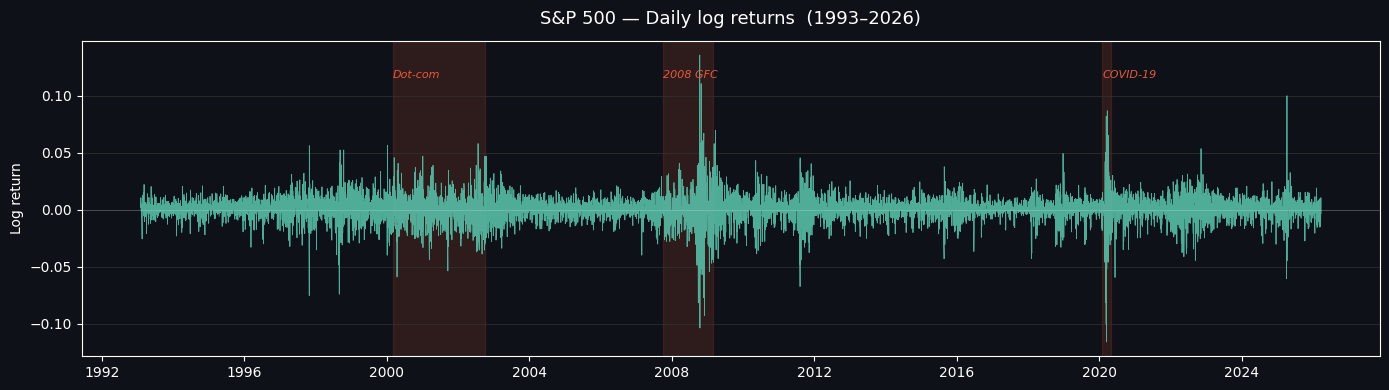

In [3]:
## --- Daily log returns over time ---

fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor('#0E1117')
ax.set_facecolor('#0E1117')

ax.plot(df.index, returns, color=ACCENT, linewidth=0.6, alpha=0.85)
ax.axhline(0, color='white', linewidth=0.4, alpha=0.3)

# Crisis periods
crises = [
    ('2000-03-01', '2002-10-01', 'Dot-com'),
    ('2007-10-01', '2009-03-01', '2008 GFC'),
    ('2020-02-01', '2020-05-01', 'COVID-19'),
]

for start, end, label in crises:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color=ACCENT2, zorder=0)
    ax.text(pd.Timestamp(start), returns.max() * 0.85, label, color=ACCENT2, fontsize=8, fontstyle='italic')

ax.set_title('S&P 500 — Daily log returns  (1993–2026)', fontsize=13, pad=12)
ax.set_ylabel('Log return')
ax.grid(axis='y', color=GRID_COL, linewidth=0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(4))

plt.tight_layout()
plt.show()

#### Log returns series

The daily log returns of the S&P 500 oscillate around zero with no visible trend,
which is consistent with the **efficient market hypothesis**: the direction of tomorrow's
return is essentially unpredictable from past returns alone.

However, the *amplitude* of these oscillations is clearly not constant over time.
Three major periods of stress are immediately visible — the dot-com crash (2000–2002),
the Global Financial Crisis (2008–2009), and the COVID shock (2020) — where the variance
of returns explodes for sustained periods before returning to a calmer baseline.

This is the first visual evidence of **volatility clustering**: large moves tend to be
followed by large moves, and calm periods tend to persist. This property will be the
foundation of our forecasting task.

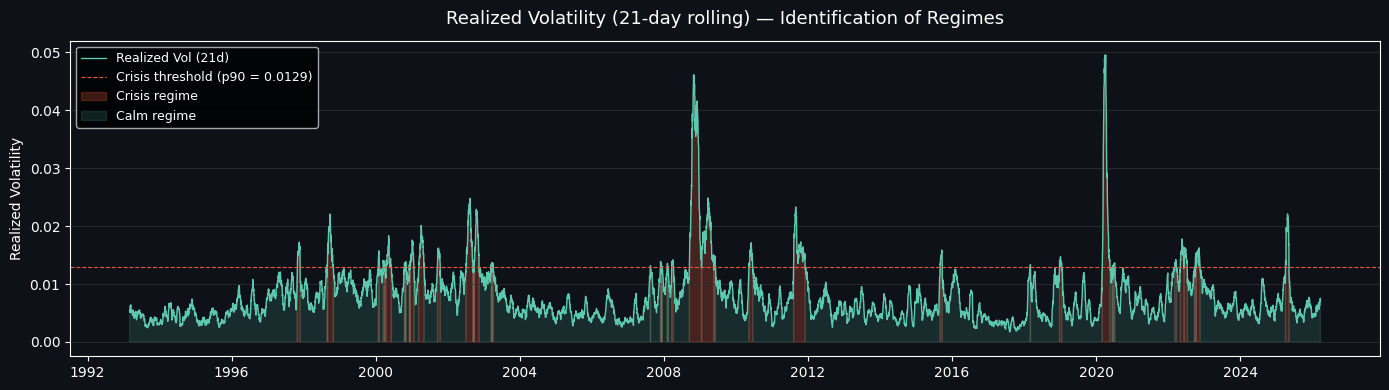

Crisis regime : 10.0% of the time
Calm regime : 90.0% of the time


In [4]:
## --- Realized volatility ---

# threshold : percentile 90 = "crisis regime"
vol_threshold = rolling_vol.quantile(0.90)

fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor('#0E1117')
ax.set_facecolor('#0E1117')

ax.plot(df.index, rolling_vol, color=ACCENT, linewidth=1.0, label='Realized Vol (21d)')
ax.axhline(vol_threshold, color=ACCENT2, linewidth=0.8, linestyle='--', label=f'Crisis threshold (p90 = {vol_threshold:.4f})')


crisis_mask = rolling_vol > vol_threshold
ax.fill_between(df.index, 0, rolling_vol,
                where=crisis_mask.values,
                color=ACCENT2, alpha=0.25, label='Crisis regime')

ax.fill_between(df.index, 0, rolling_vol,
                where=~crisis_mask.values,
                color=ACCENT, alpha=0.15, label='Calm regime')


ax.set_title('Realized Volatility (21-day rolling) — Identification of Regimes', fontsize=13, pad=12)
ax.set_ylabel('Realized Volatility')
ax.legend(fontsize=9, loc='upper left')
ax.grid(axis='y', color=GRID_COL, linewidth=0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(4))

plt.tight_layout()
plt.show()

pct_crisis = crisis_mask.mean() * 100
print(f"Crisis regime : {pct_crisis:.1f}% of the time")
print(f"Calm regime : {100 - pct_crisis:.1f}% of the time")

#### Realized volatility & regime identification

By smoothing the absolute returns over a 21-day rolling window, we get a cleaner
picture of the volatility level at each point in time. The p90 threshold separates
two distinct **market regimes**:

- **Calm regime** (~90% of the time): low, slowly-varying volatility. The market
  is in a stable state and volatility is relatively predictable from recent history.
- **Crisis regime** (~10% of the time): sharp, sudden spikes that can last weeks
  or months. These episodes are the hardest to forecast because they often involve
  a structural break from the recent past.

This regime distinction will matter when evaluating our models — a model that
performs well on average may still fail completely during crisis periods, which are
precisely the moments where accurate volatility forecasts matter most.

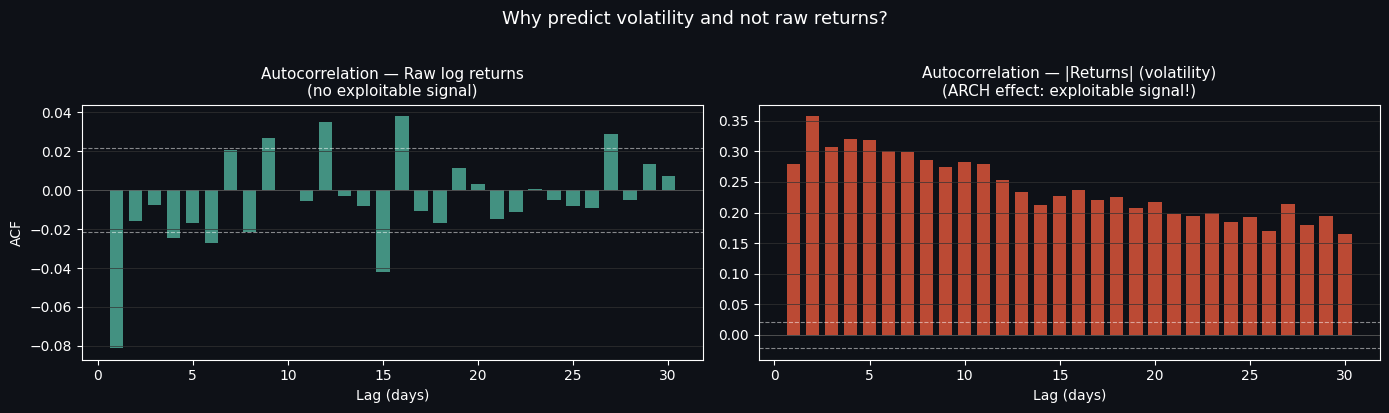

In [5]:
## --- Autocorrelation — raw returns vs |returns| ---

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.patch.set_facecolor('#0E1117')

for ax in axes:
    ax.set_facecolor('#0E1117')

lags_range = range(1, 31)
acf_returns = [returns.autocorr(lag=k) for k in lags_range]
acf_vol = [vol.autocorr(lag=k)     for k in lags_range]

# 95% confidence interval
ci = 1.96 / np.sqrt(len(returns))

axes[0].bar(list(lags_range), acf_returns, color=ACCENT, alpha=0.7, width=0.7)
axes[0].axhline( ci, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].axhline(-ci, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].axhline(0,   color='white', linewidth=0.4, alpha=0.3)
axes[0].set_title('Autocorrelation — Raw log returns\n(no exploitable signal)', fontsize=11)
axes[0].set_xlabel('Lag (days)')
axes[0].set_ylabel('ACF')
axes[0].grid(axis='y', color=GRID_COL, linewidth=0.5)

axes[1].bar(list(lags_range), acf_vol, color=ACCENT2, alpha=0.8, width=0.7)
axes[1].axhline( ci, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].axhline(-ci, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].axhline(0,   color='white', linewidth=0.4, alpha=0.3)
axes[1].set_title('Autocorrelation — |Returns| (volatility)\n(ARCH effect: exploitable signal!)', fontsize=11)
axes[1].set_xlabel('Lag (days)')
axes[1].grid(axis='y', color=GRID_COL, linewidth=0.5)

plt.suptitle('Why predict volatility and not raw returns?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

#### Autocorrelation: raw returns vs. volatility

This plot is the core justification for our forecasting task.

- **Raw log returns** (left): autocorrelation is near zero at every lag and stays
  within the 95% confidence interval. There is no exploitable linear signal —
  past returns do not predict future returns. Trying to build a model on this
  target would essentially be fitting noise.

- **Absolute returns / volatility** (right): autocorrelation is strongly positive
  and decays slowly across lags. This is the **ARCH effect** — volatility today
  is informative about volatility tomorrow, and this memory persists for several
  weeks. This is a genuine, exploitable signal.

This is why we predict `|return_t|` rather than `return_t`. The task is not to
predict market direction, but to forecast the *intensity* of future price moves.

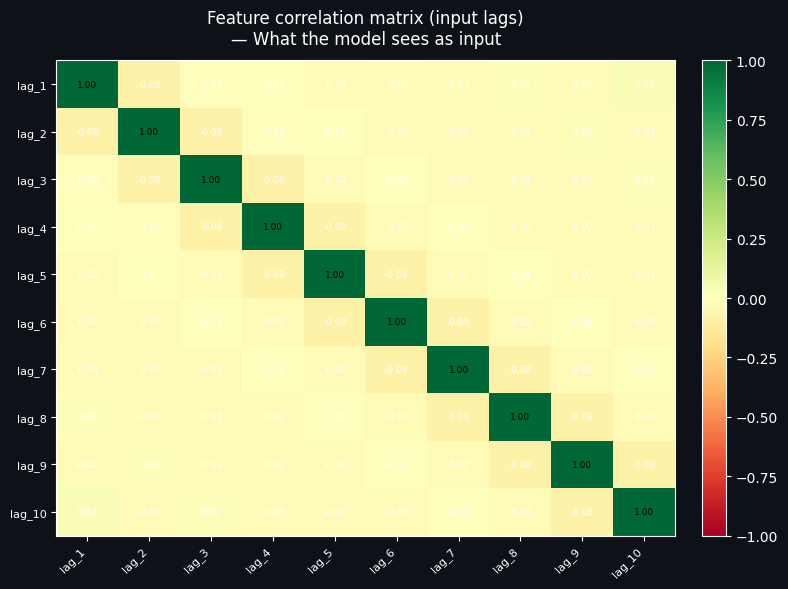

--- EDA Summary ---
• Raw returns: near-random → unpredictable (efficient market hypothesis)
• Volatility (|returns|) : strongly autocorrelated → exploitable ML signal (ARCH effect)
• Close lags are correlated with each other → watch for redundant features
• Distinct regimes exist (calm vs crisis) → model will need to handle both


In [6]:
## --- Feature Correlation Matrix ---

X_raw, y_raw = build_dataset_abs_returns(df, LAGS)
feature_cols = [f'lag_{i+1}' for i in range(LAGS)]
df_features  = pd.DataFrame(X_raw, columns=feature_cols)

corr_matrix = df_features.corr()

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0E1117')
ax.set_facecolor('#0E1117')

im = ax.imshow(corr_matrix.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(LAGS))
ax.set_yticks(range(LAGS))
ax.set_xticklabels(feature_cols, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(feature_cols, fontsize=8)

for i in range(LAGS):
    for j in range(LAGS):
        ax.text(j, i, f'{corr_matrix.values[i, j]:.2f}', ha='center', va='center', fontsize=6.5, color='black' if abs(corr_matrix.values[i, j]) > 0.5 else 'white')

ax.set_title('Feature correlation matrix (input lags)\n— What the model sees as input', fontsize=12, pad=12)

plt.tight_layout()
plt.show()

print("--- EDA Summary ---")
print("• Raw returns: near-random → unpredictable (efficient market hypothesis)")
print("• Volatility (|returns|) : strongly autocorrelated → exploitable ML signal (ARCH effect)")
print("• Close lags are correlated with each other → watch for redundant features")
print("• Distinct regimes exist (calm vs crisis) → model will need to handle both")

#### Feature correlation matrix

Our input features are the 10 most recent daily returns (`lag_1` to `lag_10`).
The correlation matrix reveals that **adjacent lags are positively correlated**
with each other: if yesterday's return was large, the day before's was likely
large too. This is a direct consequence of the volatility clustering we observed
earlier.

Two implications for our models:

1. **For linear regression**: multicollinearity between features will make
   individual coefficients less stable and harder to interpret. We should keep
   this in mind when reading the regression weights.
2. **For the FNN**: the model receives these 10 values as a flat vector with no
   notion of order. The correlations between lags carry *some* temporal signal,
   but the model cannot distinguish which lag came first — a fundamental
   limitation we will demonstrate explicitly.

### Data Analysis — Summary

The exploratory analysis establishes three key facts that will drive every
modelling decision in this notebook:

1. **Raw returns are unpredictable** — no autocorrelation, consistent with
   market efficiency. Predicting direction is not our goal.
2. **Volatility is autocorrelated** — the ARCH effect gives us a genuine
   forecasting signal. Past volatility informs future volatility.
3. **Two regimes exist** — calm (~90%) and crisis (~10%). Any model must be
   evaluated on both, as average performance can mask catastrophic failure
   during stress periods.

These observations justify using the past `LAGS` absolute returns as features
to predict next-day volatility. 

## 2- Standard Linear Regression:
 <b> Steps to do</b>
- Train a standard linear regression on the dataset
- Get the metrics, performance, significance
- Analysis of the feature the model is actually looking at, then try with new feature      (squared feature, ratio between some days etc)
- Is the model always predicting zero? 
- Correlation between the features?
- Limitation of the model?
- option: try a simple arch garch model

*all functions used to do so should be computed in the /model_analysis/regression.py file*


*Note: the baseline is trained with LAGS=10. The FNN section will show that the optimal lag window is 3 — the comparison is therefore not strictly on identical data. The linear regression MAE of 0.6377 should be interpreted as a rough baseline, not a strict apples-to-apples comparison.*

In [7]:
from model_analysis import *
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

lin_reg = LinearRegression().fit(X_train, y_train)
preds_lr = lin_reg.predict(X_test)

metrics_lr = compute_metrics(y_test, preds_lr)
print_metrics(metrics_lr, 'Linear Regression — full test set')


────────────────────────────────────────
  Linear Regression — full test set
────────────────────────────────────────
  MAE     : 0.637665
  MSE     : 0.871026
  RMSE    : 0.933288
  QLIKE   : 16.786957
────────────────────────────────────────



#### Metrics analysis

MAE and RMSE are close, which means errors are relatively uniform. The model
is not making catastrophically large mistakes on individual points, but is
consistently off across the board. The QLIKE however is high, which anticipates
what we will confirm in the regime analysis: the model systematically
underpredicts volatility spikes, exactly when accurate forecasts matter most.

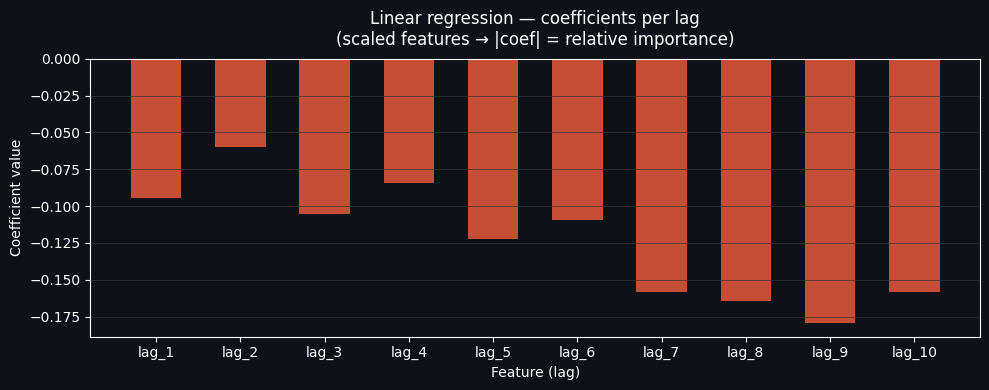

Coefficients ranked by |magnitude|:
  lag_9: -0.1796
  lag_8: -0.1641
  lag_10: -0.1586
  lag_7: -0.1582
  lag_5: -0.1227
  lag_6: -0.1097
  lag_3: -0.1055
  lag_1: -0.0944
  lag_4: -0.0844
  lag_2: -0.0596


In [8]:
feature_names = [f'lag_{i+1}' for i in range(LAGS)]
coef = lin_reg.coef_.flatten()

plot_coefficients(coef, feature_names)

importance = sorted(zip(feature_names, coef), key=lambda x: abs(x[1]), reverse=True)
print("Coefficients ranked by |magnitude|:")
for name, val in importance:
    print(f"  {name}: {val:+.4f}")

### Coefficient analysis

All coefficients are negative and small (between -0.06 and -0.18), which reveals a fundamental structural limitation of linear regression on this task.

The features X are **signed returns** — they can be positive or negative. The target y is **the absolute value of the next return** — always positive, used as a proxy for next-day volatility. A large move, whether +3% or -3%, should equally predict high volatility tomorrow.

But a linear model assigns one fixed coefficient per lag: `coef × return_t-k`. A negative coefficient means a large positive return *decreases* the predicted volatility — which is economically nonsensical. The model cannot express the relationship `|return| large → volatility large` because it has no way to treat +x and -x symmetrically.

After StandardScaler, X is centered around 0 and contains both negative and positive values, which makes this problem even worse. The model ends up with small negative coefficients everywhere — its way of giving up on finding a coherent signal.

This is precisely what a non-linear model fixes: ReLU and similar activations can learn asymmetric, magnitude-based relationships that a linear model structurally cannot.

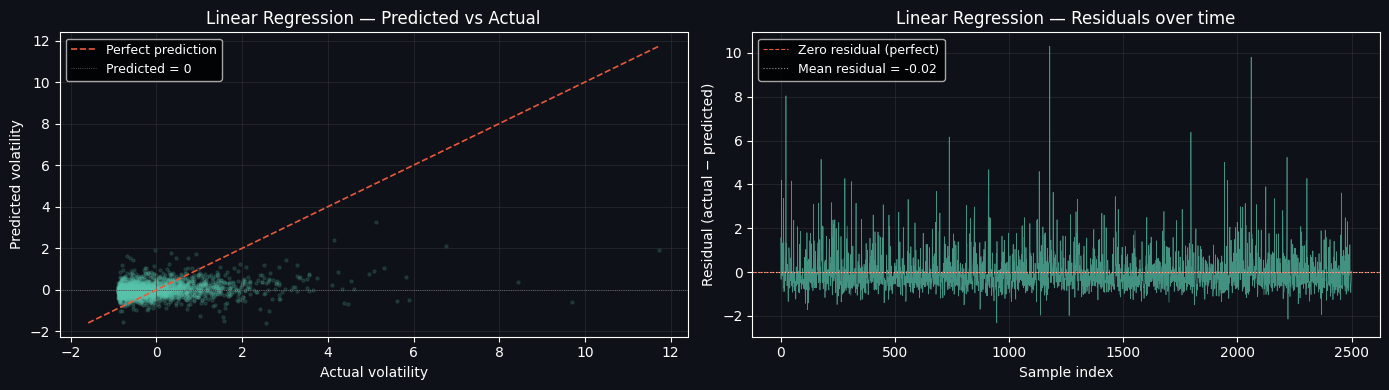

In [9]:
plot_predictions_vs_actual(y_test, preds_lr, model_name='Linear Regression')

### Predicted vs actual

The left plot answers one of the key questions of this section: **yes, the
model is almost always predicting zero**. All points collapse near the
vertical axis regardless of actual volatility — when the market moves by
6, 8 or 10 standard deviations, the model still outputs ~0. It has learned
the mean of the target and anchors to it unconditionally.

The right plot confirms the systematic nature of this failure: almost all
residuals are positive (actual > predicted), meaning the model consistently
underpredicts. The large upward spikes correspond to crisis periods — the
model's errors are largest exactly when accurate volatility forecasts matter
most.

In [10]:
# Unscaled X
X_raw, y_raw = build_dataset_abs_returns(df, LAGS)
X_squared = X_raw ** 2

# Recency ratio: lag_1 / mean(lag_2, ..., lag_5) (recent vs recent history)
mean_2_5 = X_raw[:, 1:5].mean(axis=1, keepdims=True) + 1e-8
ratio_feat = X_raw[:, [0]] / mean_2_5

X_engineered = np.hstack([X_raw, X_squared, ratio_feat])


from sklearn.preprocessing import StandardScaler
scaler_xe = StandardScaler()
scaler_ye = StandardScaler()
X_eng_s = scaler_xe.fit_transform(X_engineered)
y_eng_s = scaler_ye.fit_transform(y_raw)

X_tr_e, X_te_e, y_tr_e, y_te_e = train_test_split(X_eng_s, y_eng_s, test_size=0.3, random_state=80718)

lr_eng = LinearRegression().fit(X_tr_e, y_tr_e)
preds_eng = lr_eng.predict(X_te_e)

metrics_eng = compute_metrics(y_te_e, preds_eng)
print_metrics(metrics_eng, 'Linear Regression + engineered features')
print(f"Delta MAE (engineered vs base): {metrics_eng['MAE'] - metrics_lr['MAE']:+.6f}")


────────────────────────────────────────
  Linear Regression + engineered features
────────────────────────────────────────
  MAE     : 0.597751
  MSE     : 0.763354
  RMSE    : 0.873701
  QLIKE   : 7.462229
────────────────────────────────────────

Delta MAE (engineered vs base): -0.039914


### Feature engineering

We add two types of hand-crafted non-linear features on top of the raw lags:

- **Squared lags** (`lag_i²`): forces symmetry — a return of +3% and -3%
  both map to 0.09, allowing the model to capture amplitude regardless of
  sign. This directly addresses the structural limitation identified in the
  coefficient analysis.
- **Recency ratio** (`lag_1 / mean(lag_2..lag_5)`): captures whether
  yesterday was unusually volatile relative to the recent past, signaling
  isolated shocks vs. sustained volatility regimes.

The results confirm the intuition: MAE drops from 0.638 to 0.598 and QLIKE
is halved from 16.79 to 7.46. The improvement is real — the squared features
partially fix the symmetry problem by giving the linear model a way to see
amplitude. But the gain is limited and required explicit domain knowledge to
construct.

This is precisely what a FNN removes: rather than hand-crafting these
transformations, the network learns them automatically through its hidden
layers. And it can discover far more complex interactions than anything
we would think to engineer manually.


  Regime threshold (p90) = 1.11696
  Calm   samples : 2250 (90.0%)
  Crisis samples : 250 (10.0%)

────────────────────────────────────────
  Linear Regression — Calm regime
────────────────────────────────────────
  MAE     : 0.487705
  MSE     : 0.345387
  RMSE    : 0.587696
  QLIKE   : 15.489804
────────────────────────────────────────


────────────────────────────────────────
  Linear Regression — Crisis regime
────────────────────────────────────────
  MAE     : 1.987312
  MSE     : 5.601781
  RMSE    : 2.366808
  QLIKE   : 28.461331
────────────────────────────────────────



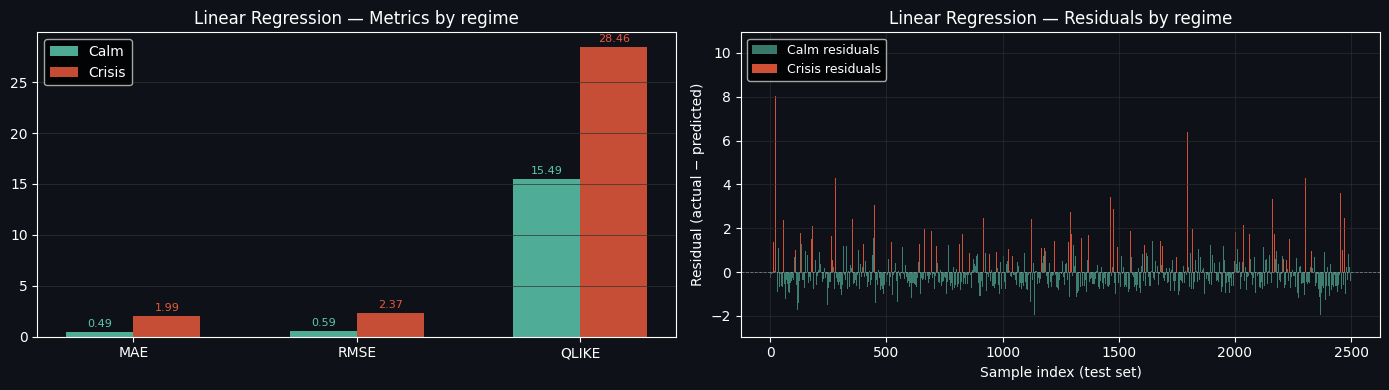

In [11]:
regime_metrics_lr = plot_performance_by_regime(y_test, preds_lr, model_name='Linear Regression', crisis_quantile=0.90)

# Benchmark for later comparison
BENCHMARK = {
    'full'  : metrics_lr,
    'calm'  : regime_metrics_lr['calm'],
    'crisis': regime_metrics_lr['crisis']
}

### Performance by regime

This is the most revealing analysis of this section. Splitting the test set
into calm (90%) and crisis (10%) periods exposes the true weakness of the
linear model.

The model is **4 times less accurate during crises than during calm periods**.
The residuals plot makes this structural: crisis errors (in red) are isolated,
large, and always positive. The model systematically underpredicts every
single volatility spike. It has no mechanism to detect that the regime has
shifted, so it keeps predicting calm-level volatility even as the market
dislocates.

This is the number the FNN will need to beat, not just the global MAE of
0.64, but specifically the crisis MAE of 1.99. A model that improves on
average but still fails during crises is not a useful volatility forecaster.

In [13]:
## ARCH/GARCH model

from arch import arch_model

raw_returns = df.iloc[:, 0].values * 100

split_idx = int(len(raw_returns) * 0.7)
train_returns = raw_returns[:split_idx]
test_returns  = raw_returns[split_idx:]

garch = arch_model(train_returns, vol='Garch', p=1, q=1, dist='normal')
garch_fit = garch.fit(disp='off')
print(garch_fit.summary())

n_test = len(test_returns)
garch_vol_preds = []

for i in range(n_test):
    model = arch_model(raw_returns[:split_idx + i], vol='Garch', p=1, q=1, dist='normal')
    res = model.fit(disp='off', show_warning=False)
    forecast = res.forecast(horizon=1)
    garch_vol_preds.append(np.sqrt(forecast.variance.values[-1, 0]))

garch_vol_preds = np.array(garch_vol_preds) / 100


_, y_raw = build_dataset_abs_returns(df, LAGS)
y_test_raw = y_raw[int(len(y_raw) * 0.7):]
y_test_raw = y_test_raw[:n_test].flatten()


min_len = min(len(y_test_raw), len(garch_vol_preds))
y_test_raw = y_test_raw[:min_len]
garch_vol_preds = np.array(garch_vol_preds[:min_len])

metrics_garch = compute_metrics(y_test_raw, garch_vol_preds)
print_metrics(metrics_garch, 'GARCH(1,1)')
print_metrics(compute_metrics(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(preds_lr)), 'Linear Regression (unscaled)')

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -8071.81
Distribution:                  Normal   AIC:                           16151.6
Method:            Maximum Likelihood   BIC:                           16178.3
                                        No. Observations:                 5840
Date:                Sun, Mar 29 2026   Df Residuals:                     5839
Time:                        14:22:08   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0646  1.074e-02      6.010  1.858e-09 [4.

In [14]:
# Extract and interpret GARCH parameters
params = garch_fit.params
alpha = params['alpha[1]']
beta = params['beta[1]']
omega = params['omega']
persistence = alpha + beta

print(f"omega (baseline variance) : {omega:.4f}")
print(f"alpha (shock sensitivity) : {alpha:.4f}")
print(f"beta  (variance persistence): {beta:.4f}")
print(f"persistence (alpha + beta)  : {persistence:.4f}")
print(f"\nHalf-life of a volatility shock: {np.log(0.5) / np.log(persistence):.1f} days")

omega (baseline variance) : 0.0159
alpha (shock sensitivity) : 0.0937
beta  (variance persistence): 0.8949
persistence (alpha + beta)  : 0.9886

Half-life of a volatility shock: 60.5 days


### GARCH(1,1) parameters

The fitted parameters reveal the underlying structure of S&P 500 volatility:

- **alpha = 0.094** (shock sensitivity): a large move today has a moderate
  but real impact on tomorrow's predicted variance
- **beta = 0.895** (persistence): yesterday's variance carries over strongly
  into today — volatility is highly persistent
- **persistence = 0.989**: extremely close to 1, meaning volatility shocks
  decay very slowly. The half-life of 60 days confirms this — a spike takes
  two months to revert to baseline on average

This is the ARCH effect captured in a parametric form: the model explicitly
encodes that volatility clusters and persists.


  Regime threshold (p90) = 0.01597
  Calm   samples : 2250 (90.0%)
  Crisis samples : 250 (10.0%)

────────────────────────────────────────
  GARCH(1,1) — Calm regime
────────────────────────────────────────
  MAE     : 0.005058
  MSE     : 0.000043
  RMSE    : 0.006594
  QLIKE   : -4.171443
────────────────────────────────────────


────────────────────────────────────────
  GARCH(1,1) — Crisis regime
────────────────────────────────────────
  MAE     : 0.012807
  MSE     : 0.000296
  RMSE    : 0.017210
  QLIKE   : -2.269153
────────────────────────────────────────



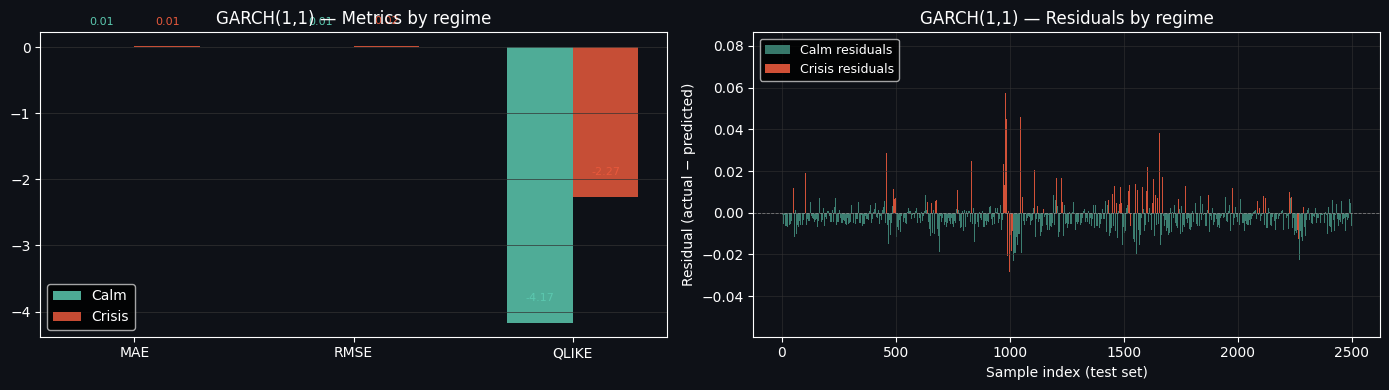

In [15]:
# Regime comparison — GARCH vs Linear Regression
regime_metrics_garch = plot_performance_by_regime(y_test_raw, garch_vol_preds, model_name='GARCH(1,1)', crisis_quantile=0.90)

### GARCH(1,1) — regime performance


GARCH improves on the linear regression during calm periods (QLIKE -4.17 vs
-3.69) but still degrades significantly during crises — crisis MAE is 2.5×
the calm MAE. The residuals plot shows the same pattern as linear regression:
isolated red spikes during crisis periods that the model fails to anticipate.

This is the fundamental limit of GARCH: it is a parametric model with a fixed
structure. It captures average volatility persistence well, but when the regime
shifts suddenly — as in 2008 or 2020 — the model has no mechanism to detect
the structural break. It keeps predicting based on its long-run parameters
while the market dislocates.

This is where a data-driven model like a FNN has a structural advantage: rather
than imposing a fixed functional form, it can learn complex non-linear patterns
directly from the data.

### Linear Regression — Summary

Two models have been evaluated as baselines for volatility forecasting:

| Model | MAE (full) | MAE (calm) | MAE (crisis) |
|-------|-----------|------------|--------------|
| Linear Regression | 0.638 | 0.488 | 1.987 |
| GARCH(1,1) | 0.006 | 0.005 | 0.013 |

Note: metrics are not directly comparable between the two models as they
operate on different scales (standardised vs raw returns). The comparison
is qualitative —> both models degrade sharply during crisis periods.

Three structural limitations have been identified across these models:

1. **Symmetry blindness** (Linear Regression): a linear model on signed
   returns cannot capture amplitude — it cannot treat +x and -x identically,
   which is a fundamental requirement for volatility forecasting.

2. **Regime blindness** (all models): every model degrades sharply during
   crisis periods. None has a mechanism to detect that the market regime has
   shifted — they all extrapolate from their training distribution and fail
   when the data distribution changes suddenly.

3. **Fixed functional form** (GARCH): despite being specifically designed
   for volatility, GARCH imposes a rigid parametric structure that cannot
   adapt to complex non-linear patterns in the data.

What we need is a model that learns its own transformations from the data,
handles non-linearity automatically, and can potentially capture more complex
interactions between past returns.